# Sentiment Analysis — Komentar YouTube "Mengapa rupiah Terus Melemah" dari youtube channel Ferry Irwandi

(https://youtu.be/2FPx1_CUzYQ?si=VG-BEUbi9JEcAQWa)



## 1. Data Scraping

In [ ]:
# !pip install youtube-comment-downloader -q

In [ ]:
# import pandas as pd
# from youtube_comment_downloader import YoutubeCommentDownloader

# pd.set_option('display.max_colwidth', None)

In [ ]:
# downloader = YoutubeCommentDownloader()

# # Catatan: hanya 1 video -> sample belum tentu representatif, pertimbangkan tambah video lain
# urls = [
#     'https://www.youtube.com/watch?v=2FPx1_CUzYQ',
# ]

# comments = []
# for url in urls:
#     for comment in downloader.get_comments_from_url(url):
#         comments.append(comment)

# df = pd.DataFrame(comments)
# df.to_csv("rupiah_melemah.csv", index=False)
# df.head()

## 2. Setup & Import

In [2]:
!pip install Sastrawi regex emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 24.0 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import regex
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords as nltk_stopwords
nltk.download('punkt')
nltk.download('stopwords')

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import torch
from transformers import pipeline

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay


from wordcloud import WordCloud
import emoji

pd.set_option('display.max_columns', None)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
DEVICE = 0 if torch.cuda.is_available() else -1
print("Device dipakai:", "GPU" if DEVICE == 0 else "CPU")

Device dipakai: CPU


## 3. Load Data

In [9]:
df = pd.read_csv("https://raw.githubusercontent.com/Rangga-a/sentiment-api/refs/heads/main/notebook/rupiah_melemah.csv")
df.head()

,Unnamed: 0,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed,paid
0,0,UgwWQwS5Eqgde_AA-kB4AaABAg,hallo warga sipil sekalian semoga ini menjelas...,1 month ago,@ferryirwandi,UCC_OYI6VZtuEZuq49Ht-cQQ,4k,387.0,https://yt3.ggpht.com/8wENFPJwQu662gR6Bhj3qgfl...,False,False,1.780714e+09,NaN
1,1,UgzxME9GhG9xCQmCRFV4AaABAg,Barang aman barang tambung habis d vili sama a...,19 hours ago,@halit-e2k,UCFMd1ttASbEy9JCwarhHRfQ,0,NaN,https://yt3.ggpht.com/ytc/AIdro_m2s7giIp50Sj11...,False,False,1.783238e+09,NaN
2,2,UgzPrzfZQ0cfUHxWNWt4AaABAg,orang desa gk pake dolar kok pada bingung 😂,1 day ago,@WawanKarjono,UCGkt2Pzj1cPR9Yx3m2VpvDA,0,NaN,https://yt3.ggpht.com/ytc/AIdro_lS4rTS_NUWN9GQ...,False,False,1.783220e+09,NaN
3,3,Ugx7TOG7apNKRVQZIdZ4AaABAg,Hilang kepercayaan investor asing. Itu penyeba...,3 days ago,@onethrudrive,UC8iE5BVTmt_HNYw2nWVI1bA,0,NaN,https://yt3.ggpht.com/ytc/AIdro_mwo8hJVjPu-CvH...,False,False,1.783047e+09,NaN
4,4,UgzCGZVMxoW6J2Prh-V4AaABAg,Bang kite kan sipil jadi kalau ada singkatan s...,5 days ago,@JAGBONSAI,UCc1Yk-7jBJi-kK2hOlMS2Uw,0,NaN,https://yt3.ggpht.com/I0xSvSn4HDp4v2zr-uDBIwEH...,False,False,1.782874e+09,NaN


## 4. EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9927 entries, 0 to 9926
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   9927 non-null   int64  
 1   cid          9927 non-null   object 
 2   text         9927 non-null   object 
 3   time         9927 non-null   object 
 4   author       9927 non-null   object 
 5   channel      9927 non-null   object 
 6   votes        9927 non-null   object 
 7   replies      370 non-null    float64
 8   photo        9927 non-null   object 
 9   heart        9927 non-null   bool   
 10  reply        9927 non-null   bool   
 11  time_parsed  9927 non-null   float64
 12  paid         4 non-null      object 
dtypes: bool(2), float64(2), int64(1), object(8)
memory usage: 872.6+ KB


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
cid,0
text,0
time,0
author,0
channel,0
votes,0
replies,9557
photo,0
heart,0


In [12]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


### Distribusi Data & Visualisasi Awal

In [13]:
df['text_length'] = df['text'].astype(str).apply(len)
print(df['text_length'].describe())

count    9927.000000
mean      126.706256
std       222.444325
min         1.000000
25%        37.000000
50%        72.000000
75%       142.000000
max      9030.000000
Name: text_length, dtype: float64


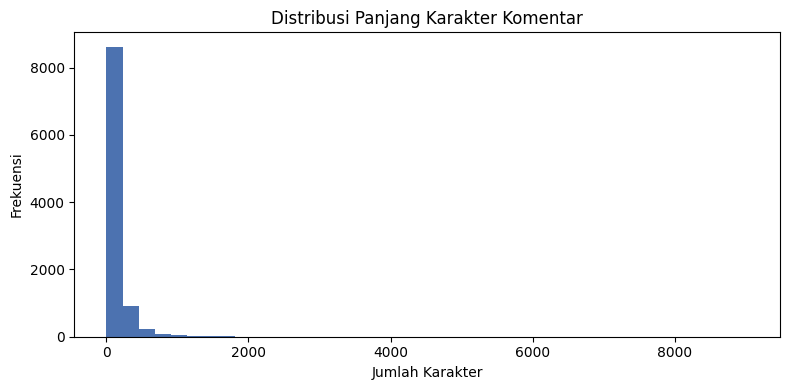

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(df['text_length'], bins=40, color='#4C72B0')
plt.title('Distribusi Panjang Karakter Komentar')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [15]:
print('Jumlah data:', len(df))

Jumlah data: 9927


## 5. Cleaning Data (kolom, duplikat, missing value)

In [16]:
df = df.drop(columns=['Unnamed: 0', 'replies', 'paid'], errors='ignore')
df.head()

,cid,text,time,author,channel,votes,photo,heart,reply,time_parsed,text_length
0,UgwWQwS5Eqgde_AA-kB4AaABAg,hallo warga sipil sekalian semoga ini menjelas...,1 month ago,@ferryirwandi,UCC_OYI6VZtuEZuq49Ht-cQQ,4k,https://yt3.ggpht.com/8wENFPJwQu662gR6Bhj3qgfl...,False,False,1.780714e+09,54
1,UgzxME9GhG9xCQmCRFV4AaABAg,Barang aman barang tambung habis d vili sama a...,19 hours ago,@halit-e2k,UCFMd1ttASbEy9JCwarhHRfQ,0,https://yt3.ggpht.com/ytc/AIdro_m2s7giIp50Sj11...,False,False,1.783238e+09,55
2,UgzPrzfZQ0cfUHxWNWt4AaABAg,orang desa gk pake dolar kok pada bingung 😂,1 day ago,@WawanKarjono,UCGkt2Pzj1cPR9Yx3m2VpvDA,0,https://yt3.ggpht.com/ytc/AIdro_lS4rTS_NUWN9GQ...,False,False,1.783220e+09,43
3,Ugx7TOG7apNKRVQZIdZ4AaABAg,Hilang kepercayaan investor asing. Itu penyeba...,3 days ago,@onethrudrive,UC8iE5BVTmt_HNYw2nWVI1bA,0,https://yt3.ggpht.com/ytc/AIdro_mwo8hJVjPu-CvH...,False,False,1.783047e+09,57
4,UgzCGZVMxoW6J2Prh-V4AaABAg,Bang kite kan sipil jadi kalau ada singkatan s...,5 days ago,@JAGBONSAI,UCc1Yk-7jBJi-kK2hOlMS2Uw,0,https://yt3.ggpht.com/I0xSvSn4HDp4v2zr-uDBIwEH...,False,False,1.782874e+09,140


In [17]:
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print("Jumlah baris setelah hapus duplikat:", len(df))

Jumlah baris setelah hapus duplikat: 9414


In [18]:
df = df.dropna(subset=['text']).reset_index(drop=True)
print("Jumlah baris setelah hapus missing text:", len(df))

Jumlah baris setelah hapus missing text: 9414


## 6. Preprocessing

### 6.1 Remove Emoji

In [ ]:
def remove_emoji(text):
    text = str(text)
    return emoji.replace_emoji(text, replace=' ')

In [ ]:
df['emoji_removed'] = df['text'].apply(remove_emoji)
df[['text', 'emoji_removed']].head()

### 6.2 Cleaning (URL, mention, angka, tanda baca, lowercase)

In [ ]:
def cleaning(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = text.replace('.', ' ').replace('_', ' ')
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df['cleaning'] = df['emoji_removed'].apply(cleaning)
df[['emoji_removed', 'cleaning']].head()

### 6.3 Tokenizing

In [ ]:
def tokenize(text):
    return text.split()

In [ ]:
df['tokenize'] = df['cleaning'].apply(tokenize)
df[['cleaning', 'tokenize']].head()

### 6.4 Normalisasi Kata Slang

In [ ]:
slang_dict = {
    'yg': 'yang',
    'utk': 'untuk',
    'dr': 'dari',
    'dlm': 'dalam',
    'pd': 'pada',
    'spy': 'supaya',
    'kr': 'karena',
    'krna': 'karena',
    'krn': 'karena',
    'trs': 'terus',
    'truz': 'terus',
    'tp': 'tapi',
    'tpi': 'tapi',
    'jd': 'jadi',
    'jdh': 'jadi',
    'jdnya': 'jadinya',
    'jg': 'juga',
    'jga': 'juga',
    'sdg': 'sedang',
    'blm': 'belum',
    'udh': 'sudah',
    'sdh': 'sudah',
    'knp': 'kenapa',
    'knpnya': 'kenapa',
    'ga': 'tidak',
    'gk': 'tidak',
    'gak': 'tidak',
    'ngga': 'tidak',
    'nggak': 'tidak',
    'engga': 'tidak',
    'enggak': 'tidak',
    'tdk': 'tidak',
    'aja': 'saja',
    'aj': 'saja',
    'doang': 'saja',
    'cm': 'cuma',
    'cmn': 'cuma',
    'kyk': 'seperti',
    'kyknya': 'sepertinya',
    'kayak': 'seperti',
    'bgt': 'banget',
    'bngt': 'banget',
    'bnget': 'banget',
    'byk': 'banyak',
    'bnyk': 'banyak',
    'sdkt': 'sedikit',
    'sm': 'sama',
    'org': 'orang',
    'ank': 'anak',
    'ortu': 'orang tua',
    'mrk': 'mereka',
    'tmn': 'teman',
    'gw': 'saya',
    'gua': 'saya',
    'gue': 'saya',
    'sy': 'saya',
    'sya': 'saya',
    'aq': 'aku',
    'ak': 'aku',
    'km': 'kamu',
    'kmu': 'kamu',
    'lu': 'kamu',
    'loe': 'kamu',
    'bs': 'bisa',
    'bsa': 'bisa',
    'dpt': 'dapat',
    'dapet': 'dapat',
    'pke': 'pakai',
    'pkai': 'pakai',
    'bwt': 'buat',
    'byr': 'bayar',
    'hr': 'hari',
    'hri': 'hari',
    'thn': 'tahun',
    'bln': 'bulan',
    'pemrintah': 'pemerintah',
    'pmrintah': 'pemerintah',
    'masyrkt': 'masyarakat',
    'rkyt': 'rakyat',
    'pres': 'presiden',
    'wapres': 'wakil presiden',
    'mpr': 'majelis permusyawaratan rakyat',
    'dpr': 'dewan perwakilan rakyat',
    'apbn': 'anggaran pendapatan dan belanja negara',
    'bbm': 'bahan bakar minyak',
    'umkm': 'usaha mikro kecil dan menengah',
    'umr': 'upah minimum regional',
    'phk': 'pemutusan hubungan kerja',
    'ojol': 'ojek online',
    'pak': 'bapak',
    'bpk': 'bapak',
    'bu': 'ibu',
    'uu': 'undang undang',
    'lg': 'lagi',
    'tlg': 'tolong',
    'smoga': 'semoga',
    'moga': 'semoga',
    'mnrt': 'menurut',
    'pdhl': 'padahal',
    'klu': 'kalau',
    'kalo': 'kalau',
    'klo': 'kalau',
    'kl': 'kalau',
    'goblk': 'goblok',
    'bg': 'bang',
    'bro': 'saudara',
    'sis': 'saudari',
    'mbg': 'makan bergizi gratis',
    'jgn': 'jangan',
    'bi': 'bank indonesia',
    'rp': 'rupiah',
    'tki': 'tenaga kerja indonesia',
    'id': 'indonesia',
    'kemenkeu': 'kementerian keuangan',
    'pinjol' : 'pinjaman online',
    'imf' : 'dana moneter internasional',
    'sbg' : 'sebagai',
    't' : 'triliun',
    'lbh' : 'lebih',
    'wni' : 'warga negara indonesia',
    'klau' : 'kalau',
    'in' : 'indonesia',
    'n' : 'dan',
    'ri' : 'republik indonesia',
    'ex' : 'mantan',
    'gen' : 'generasi',
    'sma' : 'sama',
    'sda' : 'sumber daya manusia'
}

def normalize_slang(tokens):
    return [slang_dict.get(word, word) for word in tokens]

In [ ]:
df['normalize'] = df['tokenize'].apply(normalize_slang)
df[['tokenize', 'normalize']].head()

### 6.5 Kata Negasi

Kata negasi (`tidak`, `bukan`, `belum`,
`jangan`, `tak`) digabung dengan kata sesudahnya jadi satu token
(`tidak_bagus`), supaya maknanya tidak hilang/terbalik saat stopword removal di
step berikutnya. Kalau step ini dilewati, kalimat "tidak bagus" bisa berubah jadi
seolah cuma "bagus" setelah kata "tidak" dibuang sebagai stopword.

In [ ]:
NEGATION_WORDS = {'tidak', 'bukan', 'belum', 'jangan', 'tak'}

def merge_negation(tokens):
    merged = []
    skip = False
    for i, tok in enumerate(tokens):
        if skip:
            skip = False
            continue
        if tok in NEGATION_WORDS and i + 1 < len(tokens):
            merged.append(f"{tok}_{tokens[i+1]}")
            skip = True
        else:
            merged.append(tok)
    return merged

In [ ]:
df['negation_merged'] = df['normalize'].apply(merge_negation)
df[['normalize', 'negation_merged']].head()

### 6.6 Stopword Removal (kata negasi dikecualikan)

In [ ]:
custom_stopwords = {
    'yg','dg','dgn','utk','sdh','udh','udah','sm','krn',
    'dr','trs','jd','jg','aja','aj','tp','tpi','kl','klo',
    'kalo','klu','kyk','cm','cmn','bgt','bngt','bnget',
    'bs','bsa','kau','fer','fery','ferry','tu','whats','up','brroo',
    'mas','mbak','bang','bro','broo','sis','pak','bpk','bu','om',
    'nih','dong','deh','lah','kok','kan','pun','sih',
    'ya','yah','iya','iyah','nah','eh','weh','woi',
    'ok','oke','okey','halo','hello','ka','ni',
    'aku','saya','kami','kita','kamu','anda','dia','mereka',
    'video','channel','konten','youtube','subscribe',
    'subscriber','like','share','komen','komentar',
    'admin','min','playlist',
    'orang','banyak','semua','sendiri','saja',
    'lagi','terus','baru','masih','memang',
    'jadi','buat','pakai','dapat','kalau',
    'karena','seperti','cuma','menurut',
    'padahal','tolong','semoga',
    'dll','dst','dllnya','nihh','yahh','nya','si','noh','wkwkw','lol','lmao','nihh','nih'
}

stopword_id = set(nltk_stopwords.words('indonesian'))
stopword_id.update(custom_stopwords)
stopword_id = stopword_id - NEGATION_WORDS  # kata negasi TIDAK dibuang

def remove_stopwords(tokens):
    return [w for w in tokens if w not in stopword_id]

In [ ]:
df['stopword'] = df['negation_merged'].apply(remove_stopwords)
df[['negation_merged', 'stopword']].head()

### 6.7 Stemming (Sastrawi)

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
_stem_cache = {}

def stem_word(word):
    if '_' in word:  # token hasil merge negasi, stem tiap bagian lalu gabung lagi
        parts = word.split('_')
        return '_'.join(_stem_cache.setdefault(p, stemmer.stem(p)) for p in parts)
    if word not in _stem_cache:
        _stem_cache[word] = stemmer.stem(word)
    return _stem_cache[word]

def stemming(tokens):
    return ' '.join(stem_word(w) for w in tokens)

In [ ]:
df['stemming'] = df['stopword'].apply(stemming)
df[['stopword', 'stemming']].head()

## 7. Sentiment Labeling (Model Pretrained)

In [ ]:
classifier = pipeline(
    "sentiment-analysis",
    model="Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis",
    device=DEVICE
)

In [ ]:
texts = df['stemming'].fillna('').tolist()
results = classifier(texts, truncation=True, max_length=512, batch_size=32)

In [ ]:
df['sentiment'] = [r['label'] for r in results]
df['sentiment_score'] = [r['score'] for r in results]
df['sentiment'].value_counts()

In [ ]:
sns.set_theme(style="whitegrid")
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette("pastel"))

plt.title('Distribusi Sentimen Hasil Analisis', fontsize=14, fontweight='bold', pad=20)
plt.show()

In [ ]:
wordcloud = WordCloud(
    width=1200, height=600, background_color='white',
    colormap='viridis', max_words=200
).generate(' '.join(df['stemming'].dropna().astype(str)))

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Komentar YouTube')
plt.show()

### 7.1 Top Frequent Words

In [ ]:
from collections import Counter

all_words = ' '.join(df['stemming'].dropna().astype(str)).split()
word_freq = Counter(all_words)
top_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])
top_words

In [ ]:
plt.figure(figsize=(9, 6))
plt.barh(top_words['word'][::-1], top_words['count'][::-1], color='#55A868')
plt.title('20 Kata Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.tight_layout()
plt.show()

### 7.2 WordCloud per Sentimen (Positive & Negative)

In [ ]:
unique_labels = df['sentiment'].unique().tolist()
print('Label unik yang ditemukan:', unique_labels)

pos_label = next((l for l in unique_labels if 'pos' in l.lower()), None)
neg_label = next((l for l in unique_labels if 'neg' in l.lower()), None)
print('Label positive dipakai:', pos_label)
print('Label negative dipakai:', neg_label)

In [ ]:
text_positive = ' '.join(df.loc[df['sentiment'] == pos_label, 'stemming'].dropna().astype(str))

if text_positive.strip():
    wc_pos = WordCloud(width=1200, height=600, background_color='white',
                        colormap='Greens', max_words=200).generate(text_positive)
    plt.figure(figsize=(16, 8))
    plt.imshow(wc_pos, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud - Sentimen Positive')
    plt.show()
else:
    print('Tidak ada data dengan label positive.')

In [ ]:
text_negative = ' '.join(df.loc[df['sentiment'] == neg_label, 'stemming'].dropna().astype(str))

if text_negative.strip():
    wc_neg = WordCloud(width=1200, height=600, background_color='white',
                        colormap='Reds', max_words=200).generate(text_negative)
    plt.figure(figsize=(16, 8))
    plt.imshow(wc_neg, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud - Sentimen Negative')
    plt.show()
else:
    print('Tidak ada data dengan label negative.')

### 7.3 Bigram & Trigram (Opsional)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(corpus, ngram_range, n=15):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bow = vec.transform(corpus)
    sum_words = bow.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:n], columns=['ngram', 'count'])

bigram_df = top_ngrams(df['stemming'].dropna().astype(str), ngram_range=(2, 2))
bigram_df

In [ ]:
trigram_df = top_ngrams(df['stemming'].dropna().astype(str), ngram_range=(3, 3))
trigram_df

## 8. Split Data & TF-IDF

In [ ]:
text_train, text_test, y_train, y_test = train_test_split(
    df['stemming'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
x_train = tfidf.fit_transform(text_train)
x_test = tfidf.transform(text_test)
print("Train shape:", x_train.shape, "| Test shape:", x_test.shape)

## 9. Modeling & Evaluasi (Accuracy + F1-macro + Cross-Validation)

In [ ]:
from sklearn.metrics import precision_score, recall_score

def evaluate_model(name, model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    acc = accuracy_score(y_test, pred)
    precision_macro = precision_score(y_test, pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, pred, average='macro')

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='accuracy')

    print(f"=== {name} ===")
    print(f"Test Accuracy  : {acc:.4f}")
    print(f"Test Precision : {precision_macro:.4f}")
    print(f"Test Recall    : {recall_macro:.4f}")
    print(f"Test F1-macro  : {f1_macro:.4f}")
    print(f"CV Accuracy    : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(classification_report(y_test, pred))

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': precision_macro,
        'Recall': recall_macro,
        'F1_macro': f1_macro,
        'CV_Accuracy': cv_scores.mean(),
    }

In [ ]:
results_list = []

naive_bayes = MultinomialNB()
res = evaluate_model("Naive Bayes", naive_bayes, x_train, y_train, x_test, y_test)
results_list.append(res)

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=42)
res = evaluate_model("Decision Tree", decision_tree, x_train, y_train, x_test, y_test)
results_list.append(res)

In [ ]:
random_forest = RandomForestClassifier(random_state=42)
res = evaluate_model("Random Forest", random_forest, x_train, y_train, x_test, y_test)
results_list.append(res)

In [ ]:
adaboost = AdaBoostClassifier(random_state=42)
res = evaluate_model("AdaBoost", adaboost, x_train, y_train, x_test, y_test)
results_list.append(res)

### 9.1 Linear SVM (LinearSVC)


In [ ]:
linear_svc = LinearSVC(random_state=42, max_iter=5000)
res = evaluate_model("Linear SVM", linear_svc, x_train, y_train, x_test, y_test)
results_list.append(res)

### 9.2 Logistic Regression + GridSearchCV (tuning hyperparameter)

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid.fit(x_train, y_train)
print("Best params:", grid.best_params_)

In [ ]:
logistic_regression = grid.best_estimator_
res = evaluate_model("Logistic Regression (tuned)", logistic_regression, x_train, y_train, x_test, y_test)
results_list.append(res)

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    logistic_regression, x_test, y_test, cmap='Blues'
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 10. Perbandingan Model

In [ ]:
hasil = pd.DataFrame(results_list).sort_values('F1_macro', ascending=False).reset_index(drop=True)
hasil

In [ ]:
hasil_sorted = hasil.sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(hasil_sorted['Model'], hasil_sorted['Accuracy'])
plt.ylabel("Accuracy Score")
plt.title("Perbandingan Model (Accuracy)")

for i, v in enumerate(hasil_sorted['Accuracy']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(hasil['Model'], hasil['F1_macro'])
plt.ylabel("F1-macro Score")
plt.title("Perbandingan Model (F1-macro)")
for i, v in enumerate(hasil['F1_macro']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [81]:
from sklearn.calibration import CalibratedClassifierCV

best_model_name = hasil.iloc[0]['Model']
print('Model terbaik (berdasarkan F1-macro):', best_model_name)

model_lookup = {
    'Naive Bayes': naive_bayes,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'AdaBoost': adaboost,
    'Linear SVM': linear_svc,
    'Logistic Regression (tuned)': logistic_regression,
}
raw_best_model = model_lookup[best_model_name]

if not hasattr(raw_best_model, 'predict_proba'):
    print(f"{best_model_name} tidak punya predict_proba -> kalibrasi dengan CalibratedClassifierCV")
    best_model = CalibratedClassifierCV(raw_best_model, method='sigmoid', cv=5)
    best_model.fit(x_train, y_train)
else:
    best_model = raw_best_model

pred_check = best_model.predict(x_test)
print('Model final dipakai untuk testing & deployment:', best_model_name)
print('Accuracy re-check pada test set:', accuracy_score(y_test, pred_check))
print('Kelas yang dikenali model:', list(best_model.classes_))

Model terbaik (berdasarkan F1-macro): Logistic Regression (tuned)
Model final dipakai untuk testing & deployment: Logistic Regression (tuned)
Accuracy re-check pada test set: 0.7859798194370685
Kelas yang dikenali model: ['Negative', 'Neutral', 'Positive']


## 11. Testing ke Komentar Baru

In [82]:
komentar_baru = pd.Series([
    "kebijakan pemerintah bagus",
    "rupiah makin hancur dan ekonomi buruk",
    "kebijakan ini tidak bagus untuk rakyat",
])

In [ ]:
komentar_emoji = komentar_baru.apply(remove_emoji)
komentar_clean = komentar_emoji.apply(cleaning)
komentar_token = komentar_clean.apply(tokenize)
komentar_norm = komentar_token.apply(normalize_slang)
komentar_neg = komentar_norm.apply(merge_negation)
komentar_stop = komentar_neg.apply(remove_stopwords)
komentar_stem = komentar_stop.apply(stemming)
komentar_stem

In [84]:
komentar_tfidf = tfidf.transform(komentar_stem)
prediksi = best_model.predict(komentar_tfidf)
proba = best_model.predict_proba(komentar_tfidf)
confidence = proba.max(axis=1)

for asli, bersih, p, c, prob_row in zip(komentar_baru, komentar_stem, prediksi, confidence, proba):
    print(f"Teks asli   : {asli}")
    print(f"Setelah PP  : {bersih}")
    print(f"Sentimen    : {p}")
    print(f"Confidence  : {c:.2%}")
    detail = ', '.join(f"{cls}={pr:.2%}" for cls, pr in zip(best_model.classes_, prob_row))
    print(f"Detail skor  : {detail}")
    print()

Teks asli   : kebijakan pemerintah bagus
Setelah PP  : bijak perintah bagus
Sentimen    : Positive
Confidence  : 42.03%
Semua skor  : Negative=41.52%, Neutral=16.45%, Positive=42.03%

Teks asli   : rupiah makin hancur dan ekonomi buruk
Setelah PP  : rupiah hancur ekonomi buruk
Sentimen    : Negative
Confidence  : 99.69%
Semua skor  : Negative=99.69%, Neutral=0.12%, Positive=0.19%

Teks asli   : kebijakan ini tidak bagus untuk rakyat
Setelah PP  : bijak tidak_bagus rakyat
Sentimen    : Negative
Confidence  : 93.44%
Semua skor  : Negative=93.44%, Neutral=4.89%, Positive=1.67%

Teks asli   : wah hebat sekali ya rupiah sampai segini
Setelah PP  : hebat rupiah gin
Sentimen    : Positive
Confidence  : 42.78%
Semua skor  : Negative=38.94%, Neutral=18.28%, Positive=42.78%

Teks asli   : kenapa bisa seperti ini
Setelah PP  : 
Sentimen    : Neutral
Confidence  : 48.25%
Semua skor  : Negative=46.13%, Neutral=48.25%, Positive=5.61%

Teks asli   : bagaimana ini pemerintahan
Setelah PP  : perintah
S

## 12. Export Model & Preprocessing untuk Deployment (FastAPI)

In [85]:
!pip install joblib -q

In [86]:
import joblib
import pickle
import os

os.makedirs('model_artifacts', exist_ok=True)

In [87]:
best_model_name = hasil.iloc[0]['Model']
print('Model terbaik:', best_model_name)

model_lookup = {
    'Naive Bayes': naive_bayes,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'AdaBoost': adaboost,
    'Linear SVM': linear_svc,
    'Logistic Regression (tuned)': logistic_regression,
}
best_model = model_lookup[best_model_name]

Model terbaik: Logistic Regression (tuned)


In [88]:
joblib.dump(best_model, 'model_artifacts/model.pkl')
joblib.dump(tfidf, 'model_artifacts/tfidf_vectorizer.pkl')
print('Model dan vectorizer tersimpan di folder model_artifacts/')

Model dan vectorizer tersimpan di folder model_artifacts/


In [89]:
preprocessing_assets = {
    'slang_dict': slang_dict,
    'negation_words': NEGATION_WORDS,
    'stopword_id': stopword_id,
}

with open('model_artifacts/preprocessing_assets.pkl', 'wb') as f:
    pickle.dump(preprocessing_assets, f)

print('Preprocessing assets tersimpan di model_artifacts/preprocessing_assets.pkl')

Preprocessing assets tersimpan di model_artifacts/preprocessing_assets.pkl


In [90]:
import shutil
shutil.make_archive('model_artifacts', 'zip', 'model_artifacts')
print('model_artifacts.zip siap diunduh -> pindahkan ke folder deployment FastAPI kamu.')

try:
    from google.colab import files
    files.download('model_artifacts.zip')
except ImportError:
    print('Bukan di Google Colab -> ambil file model_artifacts.zip langsung dari file browser/direktori kerja.')

model_artifacts.zip siap diunduh -> pindahkan ke folder deployment FastAPI kamu.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>